# # Learning from Small Data: Challenge 4 - Representational Limits
# 
# ## Using the MNIST Dataset
# 
# This notebook demonstrates the **fourth fundamental challenge** of learning from small data:
# 
# 1. **Extrapolation Danger**: With small data, new test points lie far from the training support → predictions are random guesses.
# 2. **Curse of Dimensionality**: As dimensions increase, data coverage becomes exponentially sparse.
# 3. **Bayesian Prior Dominance**: With small N, the prior (regularization) dominates the posterior.
# 
# **Key Question:** Why does small data force us to extrapolate blindly or rely on our assumptions?

Libraries loaded successfully!
Loading MNIST dataset...
Dataset shape: X: (10000, 784), y: (10000,)
Number of classes: 10
Training set: 7000 samples
Test set: 3000 samples


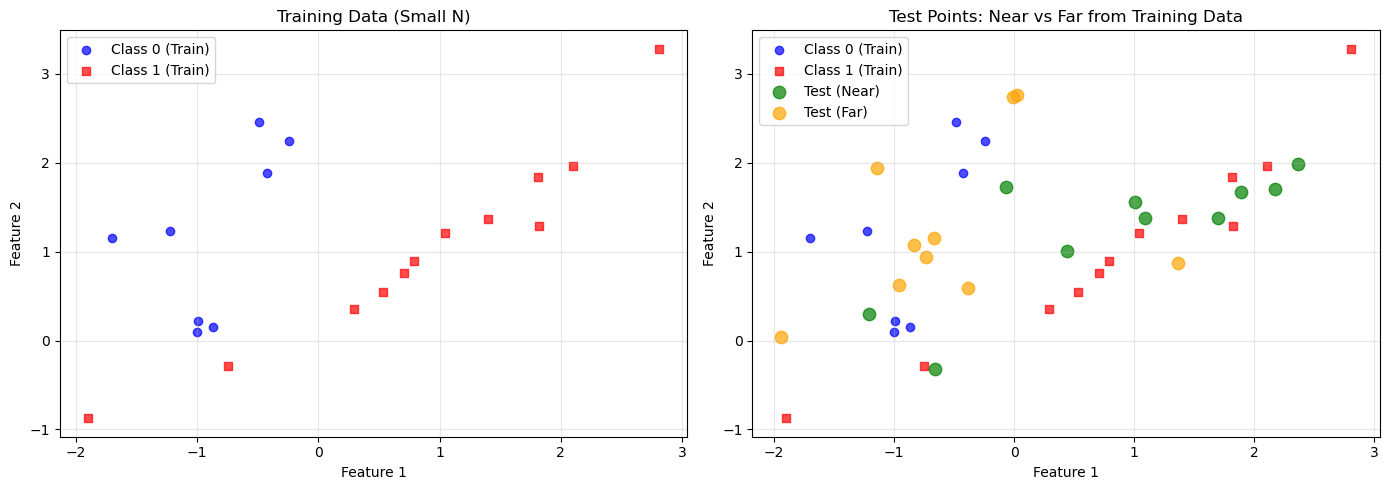

EXTRAPOLATION DEMONSTRATION (2D)
Near test points: 10
Far test points: 10


In [1]:
# ## 1. Setup and Imports

# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")

# %% [markdown]
# ## 2. Load and Prepare MNIST Dataset

# %%
# Load MNIST (using a subset for speed)
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')

# Convert to appropriate types
X = X.astype(np.float32)
y = y.astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

# Use only first 10,000 samples for faster computation
X = X[:10000]
y = y[:10000]

print(f"Dataset shape: X: {X.shape}, y: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# ## 3. Split Data: Train and Test

# %%
# Split into train (70%) and test (30%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ## 4. A Simple 2D Demonstration of Extrapolation Danger
# 
# First, let's visualize the concept of extrapolation in 2D to build intuition.

# %%
# Generate synthetic 2D data for visualization
np.random.seed(42)
n_samples_per_class = 20
X_2d, y_2d = make_classification(
    n_samples=2 * n_samples_per_class,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split into train and test
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.5, random_state=42
)

# Visualize the training data and test points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training data only
ax1 = axes[0]
scatter1 = ax1.scatter(X_train_2d[y_train_2d==0, 0], X_train_2d[y_train_2d==0, 1], 
                        c='blue', marker='o', label='Class 0 (Train)', alpha=0.7)
scatter2 = ax1.scatter(X_train_2d[y_train_2d==1, 0], X_train_2d[y_train_2d==1, 1], 
                        c='red', marker='s', label='Class 1 (Train)', alpha=0.7)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Training Data (Small N)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Training data + test points with distance information
ax2 = axes[1]
ax2.scatter(X_train_2d[y_train_2d==0, 0], X_train_2d[y_train_2d==0, 1], 
            c='blue', marker='o', label='Class 0 (Train)', alpha=0.7)
ax2.scatter(X_train_2d[y_train_2d==1, 0], X_train_2d[y_train_2d==1, 1], 
            c='red', marker='s', label='Class 1 (Train)', alpha=0.7)

# Compute distances to nearest training point for each test point
distances = cdist(X_test_2d, X_train_2d).min(axis=1)
threshold = np.percentile(distances, 50)
near_test = distances <= threshold
far_test = distances > threshold

ax2.scatter(X_test_2d[near_test, 0], X_test_2d[near_test, 1], 
            c='green', marker='o', label='Test (Near)', s=80, alpha=0.7)
ax2.scatter(X_test_2d[far_test, 0], X_test_2d[far_test, 1], 
            c='orange', marker='o', label='Test (Far)', s=80, alpha=0.7)
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_title('Test Points: Near vs Far from Training Data')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('extrapolation_2d_demo.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("EXTRAPOLATION DEMONSTRATION (2D)")
print("=" * 60)
print(f"Near test points: {np.sum(near_test)}")
print(f"Far test points: {np.sum(far_test)}")

# ### Key Observation 1: Extrapolation Danger in 2D
# 
# - **Near Test Points (Green)**: Close to training data → Model can make reliable predictions.
# - **Far Test Points (Orange)**: Far from training data → Model must extrapolate → unreliable predictions.
# 
# **With small data, the "far" region is huge!**

# %% [markdown]
# ## 5. Face 1: Extrapolation Danger with MNIST
# 
# We now demonstrate the extrapolation danger using MNIST. We train models on different amounts of data and evaluate separately on:
# - **Near Test Points**: Close to the training data.
# - **Far Test Points**: Far from the training data.

EXTRAPOLATION EXPERIMENT
N          Near Acc     Far Acc      All Acc      Near/Far    
----------------------------------------------------------------------
10         0.480     0.200     0.340     500/500
20         0.636     0.364     0.500     500/500
50         0.764     0.490     0.627     500/500
100        0.818     0.636     0.727     500/500
200        0.898     0.738     0.818     500/500
500        0.932     0.740     0.836     500/500
1000       0.952     0.762     0.857     500/500
2000       0.958     0.796     0.877     500/500


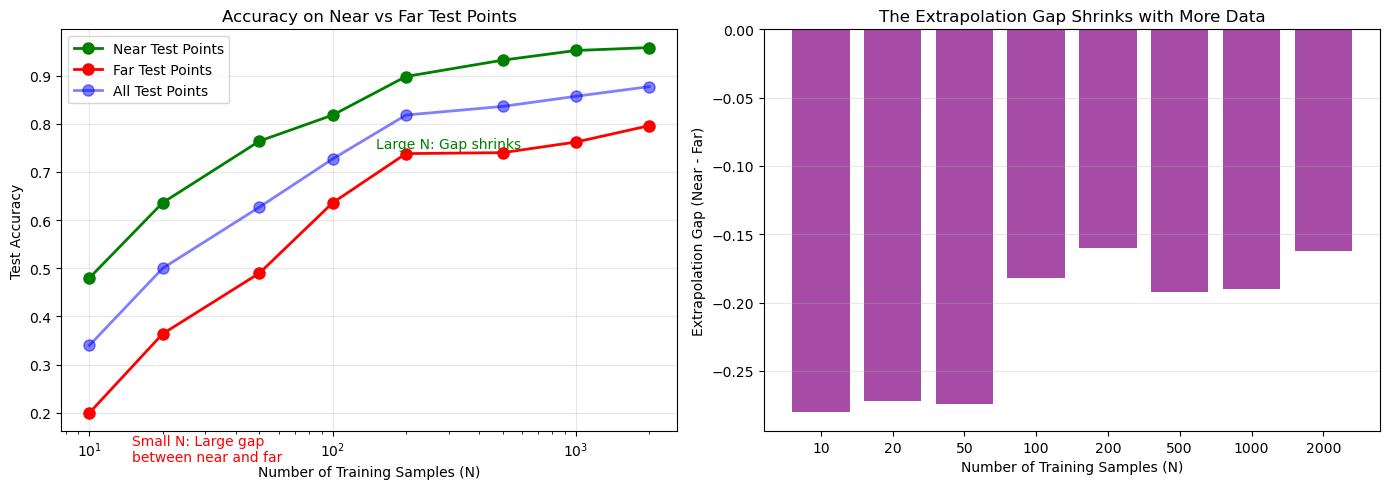

In [3]:
# %%
def compute_distance_to_training(X_train, X_test):
    """
    Compute the minimum distance from each test point to the training set.
    """
    return cdist(X_test, X_train).min(axis=1)

def get_near_far_split(X_train, X_test, percentile=50):
    """
    Split test points into near and far based on distance to training data.
    """
    distances = compute_distance_to_training(X_train, X_test)
    threshold = np.percentile(distances, percentile)
    near_mask = distances <= threshold
    far_mask = distances > threshold
    return near_mask, far_mask

def train_and_evaluate_mnist(X_train, y_train, X_test, y_test, n_samples):
    """
    Train on a subset of data and evaluate on near/far test points.
    """
    # Sample n_samples (balanced)
    n_per_class = max(1, n_samples // 10)
    indices = []
    for class_label in range(10):
        class_indices = np.where(y_train == class_label)[0]
        n_to_sample = min(n_per_class, len(class_indices))
        selected = np.random.choice(class_indices, size=n_to_sample, replace=False)
        indices.extend(selected)
    
    X_subset = X_train[indices]
    y_subset = y_train[indices]
    
    # Get near/far split based on training data
    # Use a subset of test for faster computation
    n_test_samples = min(1000, len(X_test))
    test_indices = np.random.choice(len(X_test), size=n_test_samples, replace=False)
    X_test_subset = X_test[test_indices]
    y_test_subset = y_test[test_indices]
    
    near_mask, far_mask = get_near_far_split(X_subset, X_test_subset, percentile=50)
    
    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_subset)
    X_test_scaled = scaler.transform(X_test_subset)
    
    # Train model
    model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    model.fit(X_train_scaled, y_subset)
    
    # Evaluate on near and far test points
    y_pred_near = model.predict(X_test_scaled[near_mask])
    y_pred_far = model.predict(X_test_scaled[far_mask])
    
    acc_near = accuracy_score(y_test_subset[near_mask], y_pred_near) if np.sum(near_mask) > 0 else 0
    acc_far = accuracy_score(y_test_subset[far_mask], y_pred_far) if np.sum(far_mask) > 0 else 0
    acc_all = accuracy_score(y_test_subset, model.predict(X_test_scaled))
    
    # Count near/far samples
    n_near = np.sum(near_mask)
    n_far = np.sum(far_mask)
    
    return acc_near, acc_far, acc_all, n_near, n_far

# %% [markdown]
# ### 5.1 Run Extrapolation Experiment

# %%
sample_sizes = [10, 20, 50, 100, 200, 500, 1000, 2000]
acc_near_list = []
acc_far_list = []
acc_all_list = []
n_near_list = []
n_far_list = []

print("=" * 70)
print("EXTRAPOLATION EXPERIMENT")
print("=" * 70)
print(f"{'N':<10} {'Near Acc':<12} {'Far Acc':<12} {'All Acc':<12} {'Near/Far':<12}")
print("-" * 70)

for n_samples in sample_sizes:
    acc_near, acc_far, acc_all, n_near, n_far = train_and_evaluate_mnist(
        X_train_full, y_train_full, X_test, y_test, n_samples
    )
    
    acc_near_list.append(acc_near)
    acc_far_list.append(acc_far)
    acc_all_list.append(acc_all)
    n_near_list.append(n_near)
    n_far_list.append(n_far)
    
    print(f"{n_samples:<10} {acc_near:.3f}     {acc_far:.3f}     {acc_all:.3f}     {n_near}/{n_far}")

# %% [markdown]
# ### 5.2 Visualize Extrapolation Results

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy on near vs far test points
ax1 = axes[0]
ax1.plot(sample_sizes, acc_near_list, 'o-', label='Near Test Points', color='green', linewidth=2, markersize=8)
ax1.plot(sample_sizes, acc_far_list, 'o-', label='Far Test Points', color='red', linewidth=2, markersize=8)
ax1.plot(sample_sizes, acc_all_list, 'o-', label='All Test Points', color='blue', linewidth=2, markersize=8, alpha=0.5)
ax1.set_xlabel('Number of Training Samples (N)')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Accuracy on Near vs Far Test Points')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Add annotation for the gap
ax1.text(15, 0.1, 'Small N: Large gap\nbetween near and far', fontsize=10, color='red')
ax1.text(150, 0.75, 'Large N: Gap shrinks', fontsize=10, color='green')

# Plot 2: The extrapolation gap
ax2 = axes[1]
extrapolation_gap = [f - n for n, f in zip(acc_near_list, acc_far_list)]
ax2.bar(range(len(sample_sizes)), extrapolation_gap, color='purple', alpha=0.7)
ax2.set_xticks(range(len(sample_sizes)))
ax2.set_xticklabels(sample_sizes)
ax2.set_xlabel('Number of Training Samples (N)')
ax2.set_ylabel('Extrapolation Gap (Near - Far)')
ax2.set_title('The Extrapolation Gap Shrinks with More Data')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('extrapolation_experiment.png', dpi=150, bbox_inches='tight')
plt.show()